# September 2026 desktop waterfalls — Dec-15 2025 actual → Dec-15 2026 forecast

Three waterfall charts decomposing the change in Firefox Desktop's **Dec-15 28-day trailing MA** from the 2025 actual
(51,846,238) to the September 2026 published forecast (49,545,790, display layer applied). Every bar is the change in one
tile (or group of tiles) of the canonical September desktop parquet between the two windows; bars are ordered by absolute
magnitude and close exactly to the total.

| chart | bars | file |
|---|---|---|
| OS | modern Windows (10 + 11), older Windows (pre-10), Mac + Linux + other | `plots/desktop_waterfall_os.png` |
| country | the 15 named markets + ROW | `plots/desktop_waterfall_country.png` |
| grouped country | the same markets grouped, labelled only by member names — **not** a regional view (ROW is one third of DAU) | `plots/desktop_waterfall_country_groups.png` |

Conventions decided 2026-09-04:
- The forecast has no Mac/Linux split, so the `other` tile is shown as one combined bar.
- The Win10 headwind `h` (a display-layer world total) is placed **entirely in modern Windows**, allocated across
  countries by each country's share of modern-Windows DAU in the 2026 Dec-15 window. No separate `h` bar.
- No Iran/China exclusion: both Dec-15 windows lie outside the Iran outage.
- 2025 actuals come from the parquet's `training` rows (verified equal to raw actuals).


In [1]:
# [setup]
import os
import subprocess
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"], capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")

from mozaic_daily.adjustments import load_forecast, load_adjustments_from_dir  # noqa: E402

CYCLE_DIR = "data-official/2026-09"
DESKTOP_FORECAST_PATH = (
    f"{CYCLE_DIR}/desktop_g01_2026-09-02/"
    "cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative/"
    "mozaic_daily_forecast.2026-09-02.ld-D.adj-ijlo.parquet"
)
DESKTOP_REQUIRED_STATE = ["i", "j", "l", "o"]
ADJUSTMENTS_DIR = f"{CYCLE_DIR}/adjustments"
PLOTS_DIR = f"{CYCLE_DIR}/plots"
CSV_DIR = f"{CYCLE_DIR}/csv"

FORECAST_START = pd.Timestamp("2026-09-02")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
REFERENCE_DATE = pd.Timestamp("2025-12-15")
MA_WINDOW_DAYS = 28

# Pinned published figures (csv/september_dec15_summary.csv and the canonical notebook's [gap-to-flat]); the
# waterfalls must close to these exactly or the notebook raises.
PUBLISHED_DESKTOP_DEC15_2026 = 49_545_790
PUBLISHED_DESKTOP_DEC15_2025 = 51_846_238

SEGMENT_LABELS = {
    '{"os": "modern_windows"}': "Modern Windows (10 + 11)",
    '{"os": "winX"}': "Older Windows (pre-10)",
    '{"os": "other"}': "Mac + Linux + other",
}
MODERN_WINDOWS_SEGMENT = '{"os": "modern_windows"}'
ALL_SEGMENT = '{"os": "ALL"}'

# Grouped-country chart: label is the member list, never a region name (ROW hides a third of DAU, so this is
# an analogue of a regional split, not one). Order within a label is by 2025 DAU, largest first.
COUNTRY_GROUPS = {
    "US + CA": ["US", "CA"],
    "BR + MX + AR": ["BR", "MX", "AR"],
    "DE + FR + IT": ["DE", "FR", "IT"],
    "PL + RU": ["PL", "RU"],
    "IN": ["IN"],
    "IR": ["IR"],
    "CN + JP + ID": ["CN", "JP", "ID"],
    "ROW": ["ROW"],
}

# Diverging pair from the dataviz reference palette (validated 2026-09-04: CVD dE 21.6, normal 32.3, contrast >= 3:1).
COLOR_DECREASE = "#e34948"
COLOR_INCREASE = "#2a78d6"
COLOR_TOTAL = "#8a8a86"
SHOW_DRAFT_WATERMARK = True   # flip at lock time, same policy as the canonical notebook


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_st

In [2]:
# [load-tiles]
# One 28d trailing mean per (country, segment) tile at each Dec-15. Dec-15 2026 is far beyond seam+27, where
# display_ma is byte-identical to a plain rolling(28), so a plain window mean is the published quantity.
desktop_df, desktop_meta = load_forecast(DESKTOP_FORECAST_PATH, require_state=DESKTOP_REQUIRED_STATE)
desktop_df["target_date"] = pd.to_datetime(desktop_df["target_date"])


def tile_window_means(df: pd.DataFrame, end_date: pd.Timestamp) -> pd.DataFrame:
    """Country x segment table of the trailing 28d mean DAU ending on end_date (inclusive)."""
    start_date = end_date - pd.Timedelta(days=MA_WINDOW_DAYS - 1)
    window = df[(df["target_date"] >= start_date) & (df["target_date"] <= end_date)]
    assert window["target_date"].nunique() == MA_WINDOW_DAYS, f"{end_date.date()}: window has {window['target_date'].nunique()} days"
    return window.groupby(["country", "segment"])["dau"].mean().unstack("segment")


tiles_2025 = tile_window_means(desktop_df, REFERENCE_DATE)
tiles_2026_raw = tile_window_means(desktop_df, MEASUREMENT_DATE)

# The 2025 window must be entirely training rows (real actuals), the 2026 window entirely forecast rows.
_types = desktop_df.set_index("target_date")["data_type"]
assert (_types.loc[REFERENCE_DATE - pd.Timedelta(days=27):REFERENCE_DATE] == "training").all()
assert (_types.loc[MEASUREMENT_DATE - pd.Timedelta(days=27):MEASUREMENT_DATE] == "forecast").all()

for label, tiles in [("2025", tiles_2025), ("2026 raw", tiles_2026_raw)]:
    total = tiles.loc["ALL", ALL_SEGMENT]
    assert abs(total - tiles.loc["ALL"].drop(ALL_SEGMENT).sum()) < 1, f"{label}: ALL != sum of OS segments"
    assert abs(total - tiles.drop("ALL")[ALL_SEGMENT].sum()) < 1, f"{label}: ALL != sum of countries"
    print(f"{label:9s} Dec-15 28d-MA world total {total:>13,.0f}   (ALL closes over OS segments and over countries)")
assert round(tiles_2025.loc["ALL", ALL_SEGMENT]) == PUBLISHED_DESKTOP_DEC15_2025


2025      Dec-15 28d-MA world total    51,846,238   (ALL closes over OS segments and over countries)
2026 raw  Dec-15 28d-MA world total    50,271,790   (ALL closes over OS segments and over countries)


In [3]:
# [allocate-headwind]
# The display-layer Win10 headwind `h` is a world total with no tile. Decision 2026-09-04: put all of it in
# modern Windows, allocated across countries by each country's share of modern-Windows DAU in the 2026 window.
# Read from the cycle's adjustments dir exactly as the canonical notebook does, so the Dec-15 value matches.
_index = pd.date_range(FORECAST_START, MEASUREMENT_DATE, freq="D")
net_adjustments = load_adjustments_from_dir(ADJUSTMENTS_DIR, _index, require_specs=True)
HEADWIND_DEC15 = float(net_adjustments["desktop"].get(MEASUREMENT_DATE))
print(f"desktop display layer at Dec-15: {HEADWIND_DEC15:+,.0f}")

modern_by_country = tiles_2026_raw.drop("ALL")[MODERN_WINDOWS_SEGMENT]
headwind_by_country = HEADWIND_DEC15 * modern_by_country / modern_by_country.sum()
assert abs(headwind_by_country.sum() - HEADWIND_DEC15) < 1e-6

tiles_2026 = tiles_2026_raw.copy()
tiles_2026.loc[headwind_by_country.index, MODERN_WINDOWS_SEGMENT] += headwind_by_country
tiles_2026.loc["ALL", MODERN_WINDOWS_SEGMENT] += HEADWIND_DEC15
tiles_2026.loc[headwind_by_country.index, ALL_SEGMENT] += headwind_by_country
tiles_2026.loc["ALL", ALL_SEGMENT] += HEADWIND_DEC15

assert round(tiles_2026.loc["ALL", ALL_SEGMENT]) == PUBLISHED_DESKTOP_DEC15_2026, (
    f"OS/country tiles + headwind = {tiles_2026.loc['ALL', ALL_SEGMENT]:,.0f}, published {PUBLISHED_DESKTOP_DEC15_2026:,}")
assert abs(tiles_2026.loc["ALL", ALL_SEGMENT] - tiles_2026.drop("ALL")[ALL_SEGMENT].sum()) < 1
assert abs(tiles_2026.loc["ALL", ALL_SEGMENT] - tiles_2026.loc["ALL"].drop(ALL_SEGMENT).sum()) < 1

print("\nheadwind allocation (largest 6):")
print(headwind_by_country.sort_values().head(6).round(0).astype(int).to_string())


desktop display layer at Dec-15: -726,000

headwind allocation (largest 6):
country
ROW   -236521
US     -93277
DE     -86873
FR     -53884
IN     -38458
PL     -33824


In [4]:
# [waterfall-helpers]
import textwrap


def waterfall_steps(before: pd.Series, after: pd.Series) -> pd.DataFrame:
    """Per-category delta, sorted by absolute magnitude (largest first); columns before, after, delta, share_of_total_delta."""
    steps = pd.DataFrame({"before": before, "after": after})
    steps["delta"] = steps["after"] - steps["before"]
    steps["share_of_total_delta"] = steps["delta"] / steps["delta"].sum()
    return steps.reindex(steps["delta"].abs().sort_values(ascending=False).index)


def millions(x, pos=None):
    return f"{x / 1e6:.1f}M"


def add_draft_watermark(ax, text="DRAFT"):
    if not SHOW_DRAFT_WATERMARK:
        return
    ax.text(0.5, 0.5, text, transform=ax.transAxes, fontsize=110, color="#c0392b", alpha=0.14,
            ha="center", va="center", rotation=28, zorder=100, fontweight="bold", clip_on=True)


def plot_waterfall(steps: pd.DataFrame, *, title: str, subtitle: str, savename: str,
                   start_label: str, end_label: str, figsize=(13, 7)):
    """Start total, one floating bar per row of `steps`, end total. Closes exactly by construction."""
    start_total = steps["before"].sum()
    end_total = steps["after"].sum()
    assert abs(start_total + steps["delta"].sum() - end_total) < 1e-6

    labels = [start_label, *steps.index, end_label]
    n_bars = len(labels)
    bottoms, heights, colors = [0.0], [start_total], [COLOR_TOTAL]
    running = start_total
    for delta in steps["delta"]:
        bottoms.append(running if delta >= 0 else running + delta)
        heights.append(abs(delta))
        colors.append(COLOR_INCREASE if delta >= 0 else COLOR_DECREASE)
        running += delta
    bottoms.append(0.0)
    heights.append(end_total)
    colors.append(COLOR_TOTAL)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(n_bars)
    ax.bar(x, heights, bottom=bottoms, color=colors, width=0.62, edgecolor="#fcfcfb", linewidth=1.5, zorder=3)

    # Thin connectors from each bar's landing level to the next bar.
    level = start_total
    for i, delta in enumerate(steps["delta"]):
        ax.plot([i + 0.31, i + 1 - 0.31], [level, level], color="#8a8a86", linewidth=0.8, zorder=2)
        level += delta
    ax.plot([n_bars - 2 + 0.31, n_bars - 1 - 0.31], [level, level], color="#8a8a86", linewidth=0.8, zorder=2)

    # Direct labels: totals on the end bars, signed deltas on the floating bars (text tokens, never series color).
    y_lo = min(end_total, start_total) - 0.55 * max(heights[1:-1] + [1.0])
    y_hi = max(end_total, start_total) + 0.55 * max(heights[1:-1] + [1.0])
    pad = (y_hi - y_lo) * 0.012
    ax.text(0, start_total + pad, f"{start_total:,.0f}", ha="center", va="bottom", fontsize=9.5, color="#333")
    ax.text(n_bars - 1, end_total + pad, f"{end_total:,.0f}", ha="center", va="bottom", fontsize=9.5, color="#333")
    for i, delta in enumerate(steps["delta"], start=1):
        top = bottoms[i] + heights[i]
        ax.text(i, top + pad, f"{delta:+,.0f}", ha="center", va="bottom", fontsize=9, color="#333")

    ax.set_ylim(y_lo, y_hi)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=9.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
    ax.set_ylabel("Desktop DAU, 28-day trailing MA")
    # Headline at figure level, wrapped subtitle in the axes-title slot so neither overlaps or overflows.
    wrap_width = int(figsize[0] * 11)
    ax.set_title("\n".join(textwrap.wrap(subtitle, wrap_width)), fontsize=9.5, color="#555", loc="left", pad=8)
    fig.suptitle(title, fontsize=14, x=0.01, ha="left")
    ax.grid(True, axis="y", alpha=0.25, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    add_draft_watermark(ax)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


def print_steps(title: str, steps: pd.DataFrame):
    print(title)
    header = f"{'category':<28s} {'Dec-15 2025':>14s} {'Dec-15 2026':>14s} {'delta':>12s} {'% of 2025':>10s} {'share':>7s}"
    print(header)
    print("-" * len(header))
    for name, row in steps.iterrows():
        print(f"{name:<28s} {row.before:>14,.0f} {row.after:>14,.0f} {row.delta:>+12,.0f} "
              f"{row.delta / row.before * 100:>+9.2f}% {row.share_of_total_delta * 100:>6.1f}%")
    print(f"{'TOTAL':<28s} {steps.before.sum():>14,.0f} {steps.after.sum():>14,.0f} {steps.delta.sum():>+12,.0f} "
          f"{steps.delta.sum() / steps.before.sum() * 100:>+9.2f}%")


START_LABEL = "Dec 15, 2025\n(actual)"
END_LABEL = "Dec 15, 2026\n(Sep forecast)"


DESKTOP by OS — Dec-15 28d-MA, 2025 actual → 2026 September forecast (h in modern Windows)
category                        Dec-15 2025    Dec-15 2026        delta  % of 2025   share
------------------------------------------------------------------------------------------
Modern Windows (10 + 11)         41,343,791     39,732,744   -1,611,048     -3.90%   70.0%
Older Windows (pre-10)            3,613,168      2,487,832   -1,125,336    -31.15%   48.9%
Mac + Linux + other               6,889,278      7,325,214     +435,937     +6.33%  -19.0%
TOTAL                            51,846,238     49,545,790   -2,300,447     -4.44%
saved: data-official/2026-09/plots/desktop_waterfall_os.png


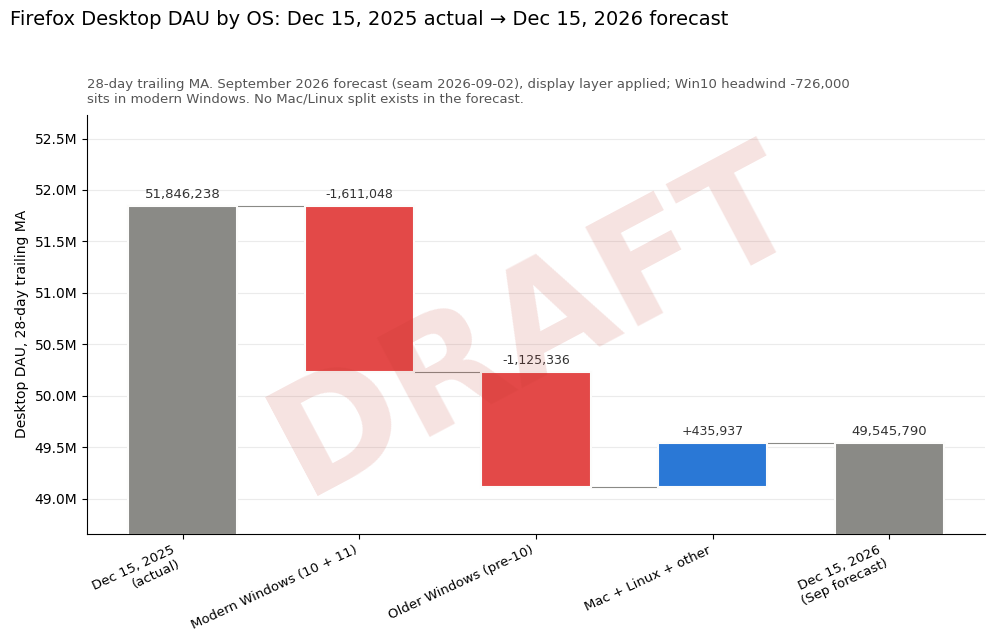

In [5]:
# [plot-os]
os_steps = waterfall_steps(
    tiles_2025.loc["ALL"].drop(ALL_SEGMENT).rename(SEGMENT_LABELS),
    tiles_2026.loc["ALL"].drop(ALL_SEGMENT).rename(SEGMENT_LABELS),
)
print_steps("DESKTOP by OS — Dec-15 28d-MA, 2025 actual → 2026 September forecast (h in modern Windows)", os_steps)
plot_waterfall(
    os_steps,
    title="Firefox Desktop DAU by OS: Dec 15, 2025 actual → Dec 15, 2026 forecast",
    subtitle=f"28-day trailing MA. September 2026 forecast (seam {FORECAST_START.date()}), display layer applied; "
             f"Win10 headwind {HEADWIND_DEC15:+,.0f} sits in modern Windows. No Mac/Linux split exists in the forecast.",
    savename="desktop_waterfall_os.png", start_label=START_LABEL, end_label=END_LABEL, figsize=(10, 6.5),
)


DESKTOP by country — Dec-15 28d-MA, 2025 actual → 2026 September forecast
category                        Dec-15 2025    Dec-15 2026        delta  % of 2025   share
------------------------------------------------------------------------------------------
ROW                              17,213,360     16,224,621     -988,740     -5.74%   43.0%
CN                                1,103,402      2,023,772     +920,370    +83.41%  -40.0%
US                                7,404,090      6,918,290     -485,799     -6.56%   21.1%
DE                                6,036,684      5,603,794     -432,890     -7.17%   18.8%
FR                                3,990,364      3,668,572     -321,792     -8.06%   14.0%
PL                                2,283,548      2,078,487     -205,061     -8.98%    8.9%
ID                                1,679,697      1,490,599     -189,097    -11.26%    8.2%
RU                                1,580,310      1,421,065     -159,245    -10.08%    6.9%
IT              

saved: data-official/2026-09/plots/desktop_waterfall_country.png


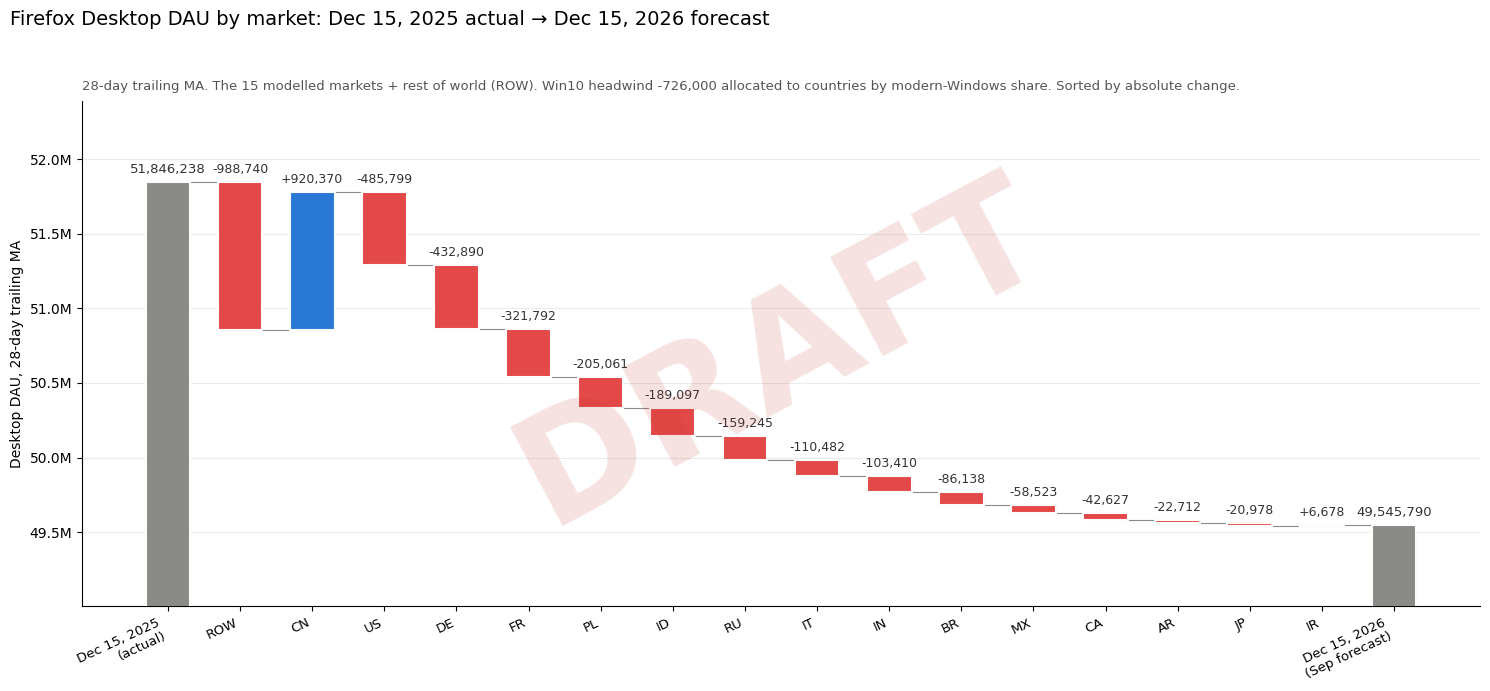

In [6]:
# [plot-country]
country_steps = waterfall_steps(tiles_2025.drop("ALL")[ALL_SEGMENT], tiles_2026.drop("ALL")[ALL_SEGMENT])
print_steps("DESKTOP by country — Dec-15 28d-MA, 2025 actual → 2026 September forecast", country_steps)
plot_waterfall(
    country_steps,
    title="Firefox Desktop DAU by market: Dec 15, 2025 actual → Dec 15, 2026 forecast",
    subtitle=f"28-day trailing MA. The 15 modelled markets + rest of world (ROW). Win10 headwind {HEADWIND_DEC15:+,.0f} "
             "allocated to countries by modern-Windows share. Sorted by absolute change.",
    savename="desktop_waterfall_country.png", start_label=START_LABEL, end_label=END_LABEL, figsize=(15, 7),
)


DESKTOP by market group — Dec-15 28d-MA, 2025 actual → 2026 September forecast
category                        Dec-15 2025    Dec-15 2026        delta  % of 2025   share
------------------------------------------------------------------------------------------
ROW                              17,213,360     16,224,621     -988,740     -5.74%   43.0%
DE + FR + IT                     11,472,434     10,607,270     -865,165     -7.54%   37.6%
CN + JP + ID                      3,916,240      4,626,535     +710,295    +18.14%  -30.9%
US + CA                           8,582,816      8,054,389     -528,427     -6.16%   23.0%
PL + RU                           3,863,858      3,499,552     -364,306     -9.43%   15.8%
BR + MX + AR                      3,093,512      2,926,139     -167,374     -5.41%    7.3%
IN                                2,775,935      2,672,526     -103,410     -3.73%    4.5%
IR                                  928,082        934,760       +6,678     +0.72%   -0.3%
TOTAL      

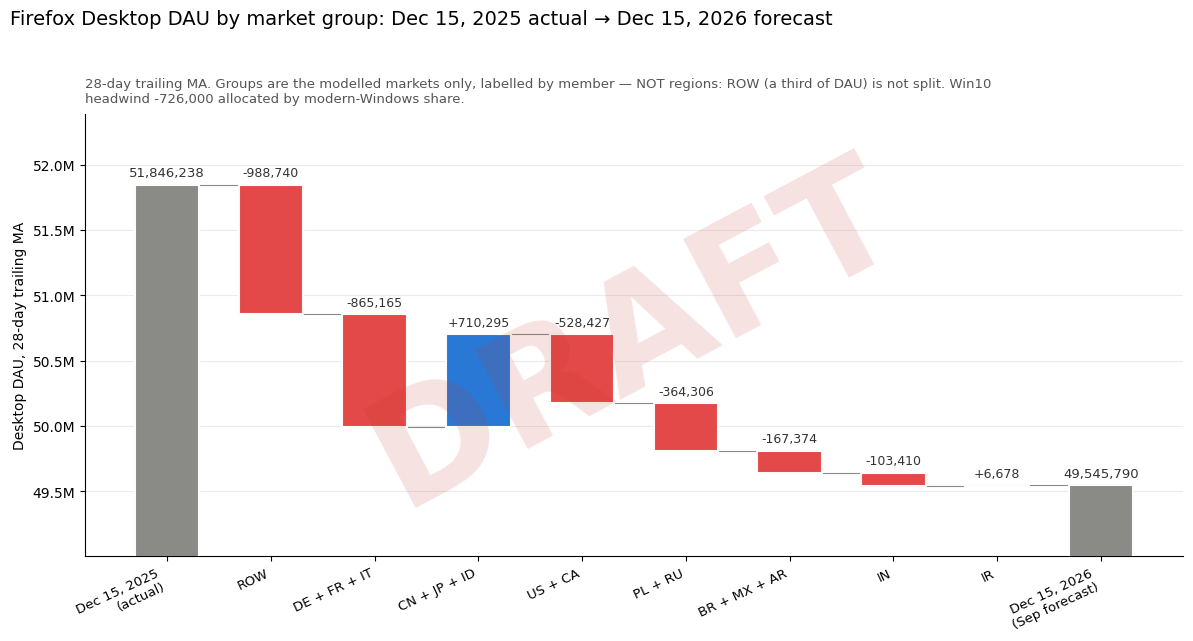

In [7]:
# [plot-country-groups]
_members = [c for members in COUNTRY_GROUPS.values() for c in members]
assert sorted(_members) == sorted(tiles_2025.drop("ALL").index), "COUNTRY_GROUPS must cover every country tile exactly once"


def group_totals(tiles: pd.DataFrame) -> pd.Series:
    return pd.Series({label: tiles.loc[members, ALL_SEGMENT].sum() for label, members in COUNTRY_GROUPS.items()})


group_steps = waterfall_steps(group_totals(tiles_2025), group_totals(tiles_2026))
print_steps("DESKTOP by market group — Dec-15 28d-MA, 2025 actual → 2026 September forecast", group_steps)
plot_waterfall(
    group_steps,
    title="Firefox Desktop DAU by market group: Dec 15, 2025 actual → Dec 15, 2026 forecast",
    subtitle="28-day trailing MA. Groups are the modelled markets only, labelled by member — NOT regions: ROW (a third of DAU) "
             f"is not split. Win10 headwind {HEADWIND_DEC15:+,.0f} allocated by modern-Windows share.",
    savename="desktop_waterfall_country_groups.png", start_label=START_LABEL, end_label=END_LABEL, figsize=(12, 6.5),
)


In [8]:
# [csv-export]
# One long table of every bar on the three charts, for the write-up. Values are the unrounded window means.
export = pd.concat(
    {"os": os_steps, "country": country_steps, "country_group": group_steps}, names=["chart", "category"]
).reset_index()
export["headwind_placement"] = "modern_windows, allocated by 2026 modern-Windows share"
out = f"{CSV_DIR}/september_desktop_waterfall_steps.csv"
export.to_csv(out, index=False)
print(f"saved: {out}  ({len(export)} rows)")


saved: data-official/2026-09/csv/september_desktop_waterfall_steps.csv  (27 rows)
